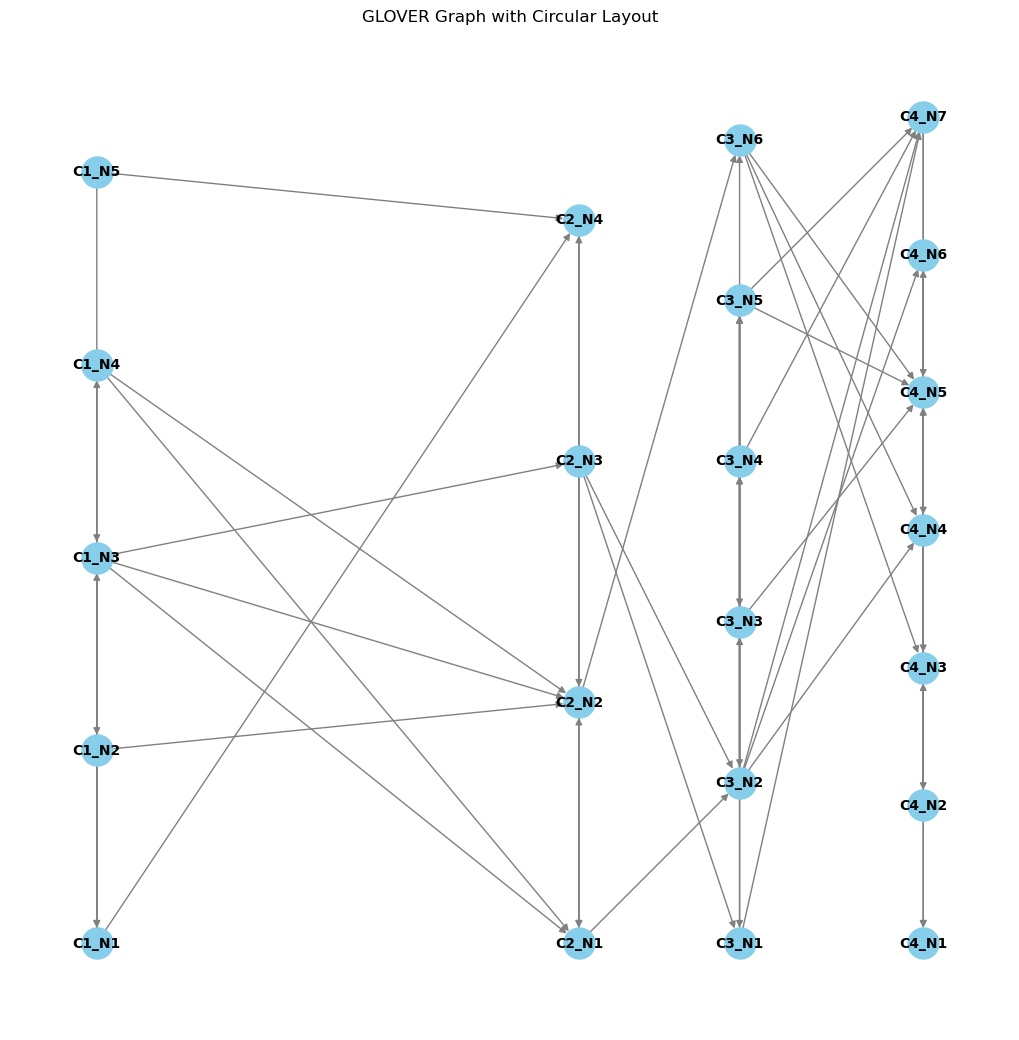

In [22]:
import networkx as nx
import random
import matplotlib.pyplot as plt

def generate_glover_graph(levels, nodes_per_level, edge_prob=0.3):
    G = nx.DiGraph()  # Directed graph for queue relationships
    node_id = 1
    levels_dict = {}
    
    # Create nodes and assign to levels
    for i in range(levels):
        level_nodes = [f'C{i+1}_N{j+1}' for j in range(nodes_per_level[i])]
        levels_dict[f'C{i+1}'] = level_nodes
        G.add_nodes_from(level_nodes)
        node_id += len(level_nodes)

    # Add edges based on probabilities
    for i, level_nodes in enumerate(levels_dict.values()):
        # Interior neighbors
        for u in level_nodes:
            for v in level_nodes:
                if u != v and random.random() < edge_prob:
                    G.add_edge(u, v)

        # Exterior neighbors
        if i < len(levels_dict) - 1:
            next_level_nodes = list(levels_dict.values())[i + 1]
            for u in level_nodes:
                for v in next_level_nodes:
                    if random.random() < edge_prob:
                        G.add_edge(u, v)

    return G, levels_dict

def circular_layout_levels(G, levels_dict):
    pos = {}
    radius = 10  # Start radius for circular layout

    for i, (level, nodes) in enumerate(levels_dict.items()):
        # Increase the radius for each level to space them out
        angle_step = 2 * 3.14159 / len(nodes)  # Angle step for even distribution in the circle
        level_pos = {
            node: (radius * 2 * i * (3.14159 / 2) * (angle_step), angle_step * j)
            for j, node in enumerate(nodes)
        }
        pos.update(level_pos)

    return pos

# Example: Generate a 3-level GLOVER graph
levels = 4
nodes_per_level = [5, 4, 6, 7]  # Specify number of nodes per level
graph, levels_dict = generate_glover_graph(levels, nodes_per_level)

# Use a custom circular layout function to arrange nodes in circles
pos = circular_layout_levels(graph, levels_dict)

# Draw the graph with the circular layout
plt.figure(figsize=(10, 10))
nx.draw(graph, pos, with_labels=True, node_size=500, node_color="skyblue", font_size=10, font_weight="bold", edge_color="gray")
plt.title("GLOVER Graph with Circular Layout")
plt.show()


In [5]:
def label_glover_graph(G, levels_dict):
    # Add container and rank labels to nodes
    for container, nodes in levels_dict.items():
        for rank, node in enumerate(nodes, start=1):
            G.nodes[node]['container'] = container
            G.nodes[node]['rank'] = rank

    # Label edges as interior or exterior
    for u, v in G.edges:
        if G.nodes[u]['container'] == G.nodes[v]['container']:
            G.edges[u, v]['type'] = 'interior'
        else:
            G.edges[u, v]['type'] = 'exterior'


In [25]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_glover_graph(G):
    pos = nx.spring_layout(G)
    edge_colors = ['blue' if G.edges[edge]['type'] == 'interior' else 'green' for edge in G.edges]
    nx.draw(G, pos, with_labels=True, edge_color=edge_colors, node_size=700, font_size=10)
    plt.show()

plot_glover_graph(G)


KeyError: 'type'

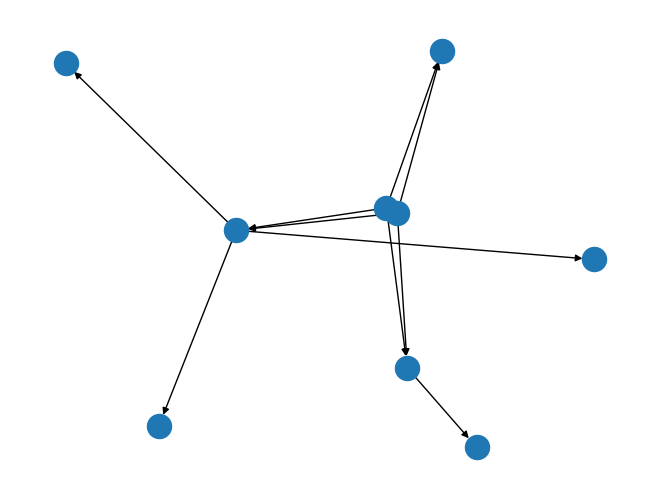

In [28]:
import networkx as nx
import random

def simulate_supply_chain():
    G = nx.DiGraph()
    levels = {'C1': ['Supplier1', 'Supplier2'], 
              'C2': ['Warehouse1', 'Warehouse2', 'Warehouse3'], 
              'C3': ['Retailer1', 'Retailer2', 'Retailer3', 'Retailer4']}
    
    # Add nodes with container labels
    for container, nodes in levels.items():
        for node in nodes:
            G.add_node(node, container=container)
    
    # Add random weighted edges
    for supplier in levels['C1']:
        for warehouse in levels['C2']:
            if random.random() < 0.7:  # 70% chance of connection
                G.add_edge(supplier, warehouse, weight=random.randint(10, 100))
    
    for warehouse in levels['C2']:
        for retailer in levels['C3']:
            if random.random() < 0.5:  # 50% chance of connection
                G.add_edge(warehouse, retailer, weight=random.randint(10, 100))
    
    return G

G = simulate_supply_chain()
nx.draw(G)

In [8]:
import networkx as nx
import random

def generate_social_network():
    G = nx.DiGraph()
    
    # Define levels and users in each level
    levels = {
        'C1': ['Influencer1', 'Influencer2', 'Influencer3'],
        'C2': [f'ActiveUser{i}' for i in range(1, 6)],
        'C3': [f'CasualUser{i}' for i in range(1, 11)]
    }
    
    # Add nodes with container labels
    for container, nodes in levels.items():
        for node in nodes:
            G.add_node(node, container=container)
    
    # Add random connections (interior and exterior)
    for container, nodes in levels.items():
        # Interior connections within the same container
        for i, u in enumerate(nodes):
            for v in nodes[i + 1:]:
                if random.random() < 0.4:  # 40% chance of connection
                    G.add_edge(u, v, type='interior', weight=random.randint(1, 10))
        
        # Exterior connections to the next level
        if container != 'C3':  # Skip the last level
            next_level = list(levels.values())[list(levels.keys()).index(container) + 1]
            for u in nodes:
                for v in next_level:
                    if random.random() < 0.6:  # 60% chance of connection
                        G.add_edge(u, v, type='exterior', weight=random.randint(1, 10))
    
    return G

# Generate the social network graph
social_network = generate_social_network()


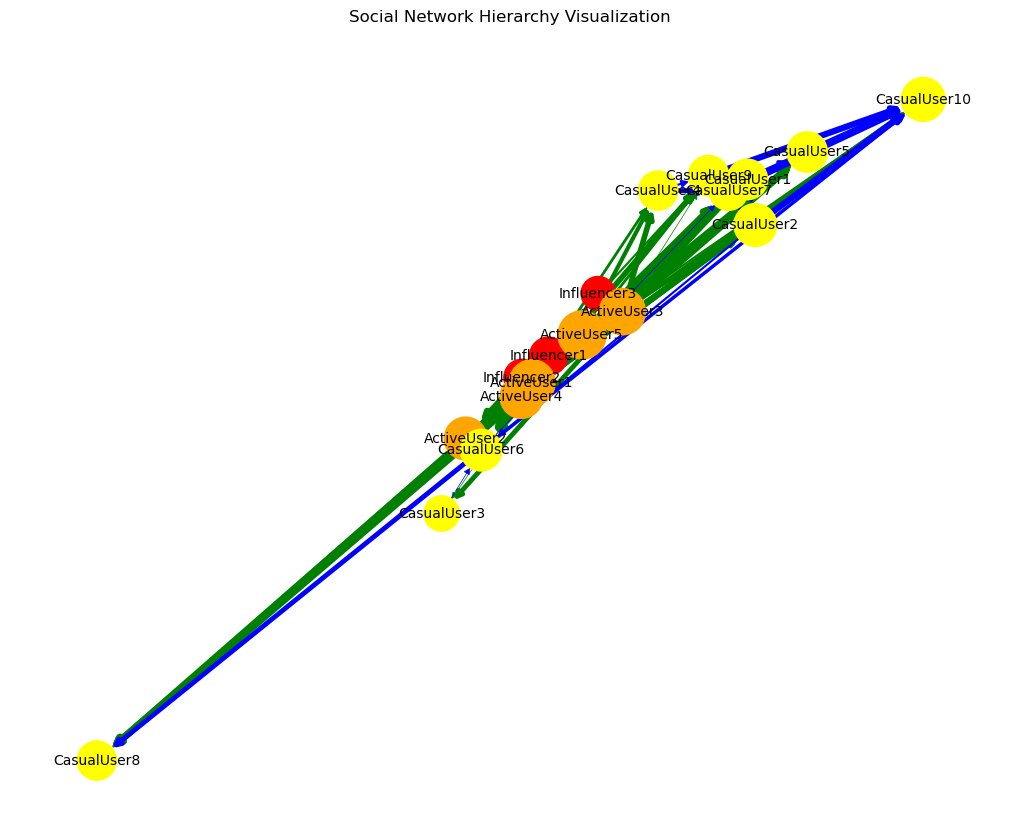

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_social_network(G):
    # Define colors for nodes based on containers
    container_colors = {
        'C1': 'red',
        'C2': 'orange',
        'C3': 'yellow'
    }
    node_colors = [container_colors[G.nodes[node]['container']] for node in G.nodes]
    
    # Define edge colors and widths
    edge_colors = ['blue' if G.edges[edge]['type'] == 'interior' else 'green' for edge in G.edges]
    edge_widths = [G.edges[edge]['weight'] / 2 for edge in G.edges]
    
    # Define node sizes (based on degree)
    node_sizes = [500 + 50 * G.degree[node] for node in G.nodes]
    
    # Layout and plot
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=node_sizes,
        width=edge_widths,
        font_size=10
    )
    plt.title("Social Network Hierarchy Visualization")
    plt.show()

# Call the visualization function
plot_social_network(social_network)


In [45]:
import json

def save_graph_to_json(G, filename="social_network.json"):
    graph_data = {
        "nodes": [],
        "edges": []
    }
    
    # Serialize nodes
    for node, data in G.nodes(data=True):
        graph_data["nodes"].append({
            "id": node,
#            "container": data['container'],
            "degree": G.degree[node]
        })
    
    # Serialize edges
    for u, v, data in G.edges(data=True):
        graph_data["edges"].append({
            "source": u,
            "target": v,
            "type": data['type'],
            "weight": data['weight']
        })
    
    # Write to JSON file
    with open(filename, 'w') as f:
        json.dump(graph_data, f, indent=4)
    print(f"Graph data written to {filename}")

# Call the function to save the graph data
save_graph_to_json(social_network)


KeyError: 'type'

In [29]:
import random
import json

# List of dishes with their types, origins, and descriptions (provided data)
dishes = [
    {"id": 1, "name": "Spaghetti Bolognese", "type": "Main Course", "origin": "Italian", "description": "A rich meat sauce served over spaghetti, simmered with tomatoes, onions, and herbs."},
    {"id": 2, "name": "Tiramisu", "type": "Dessert", "origin": "Italian", "description": "Layers of coffee-soaked ladyfingers and mascarpone cream, topped with cocoa powder."},
    {"id": 3, "name": "Tacos", "type": "Main Course", "origin": "Mexican", "description": "Soft corn or flour tortillas filled with seasoned meat, fresh vegetables, and salsa."},
    {"id": 4, "name": "Churros", "type": "Dessert", "origin": "Mexican", "description": "Deep-fried dough sticks dusted with cinnamon sugar, often dipped in chocolate."},
    {"id": 5, "name": "Hamburger", "type": "Main Course", "origin": "American", "description": "A grilled beef patty served on a bun with lettuce, tomato, and condiments."},
    {"id": 6, "name": "Apple Pie", "type": "Dessert", "origin": "American", "description": "A baked pastry with a spiced apple filling, often served with vanilla ice cream."},
    {"id": 7, "name": "Lasagna", "type": "Main Course", "origin": "Italian", "description": "Layered pasta with meat, tomato sauce, ricotta, and mozzarella, baked to perfection."},
    {"id": 8, "name": "Panna Cotta", "type": "Dessert", "origin": "Italian", "description": "A creamy, chilled dessert set with gelatin and served with a fruity topping."},
    {"id": 9, "name": "Burritos", "type": "Main Course", "origin": "Mexican", "description": "Large flour tortillas wrapped around meat, beans, rice, and salsa."},
    {"id": 10, "name": "Flan", "type": "Dessert", "origin": "Mexican", "description": "A smooth, caramel-topped custard baked in a water bath."},
    {"id": 11, "name": "Chicken Caesar Salad", "type": "Appetizer", "origin": "American", "description": "Crisp romaine lettuce with grilled chicken, croutons, and Caesar dressing."},
    {"id": 12, "name": "Guacamole", "type": "Appetizer", "origin": "Mexican", "description": "A creamy dip made from mashed avocados, lime juice, and fresh cilantro."},
    {"id": 13, "name": "Bruschetta", "type": "Appetizer", "origin": "Italian", "description": "Grilled bread topped with fresh tomatoes, garlic, basil, and olive oil."},
    {"id": 14, "name": "Steak Frites", "type": "Main Course", "origin": "French", "description": "Seared steak served with a side of crispy French fries."},
    {"id": 15, "name": "Crepes", "type": "Dessert", "origin": "French", "description": "Thin, delicate pancakes often filled with fruit, chocolate, or cream."},
    {"id": 16, "name": "Paella", "type": "Main Course", "origin": "Spanish", "description": "A saffron-infused rice dish with seafood, meats, and vegetables."},
    {"id": 17, "name": "Churros", "type": "Dessert", "origin": "Spanish", "description": "Fried dough pastries sprinkled with sugar, popular as a street food."},
    {"id": 18, "name": "Sushi", "type": "Main Course", "origin": "Japanese", "description": "Vinegared rice topped with raw fish, vegetables, and seaweed wraps."},
    {"id": 19, "name": "Mochi", "type": "Dessert", "origin": "Japanese", "description": "Chewy rice cakes with a sweet filling, often dusted with cornstarch."},
    {"id": 20, "name": "Peking Duck", "type": "Main Course", "origin": "Chinese", "description": "Crispy roasted duck served with pancakes, hoisin sauce, and green onions."},
    {"id": 21, "name": "Fortune Cookies", "type": "Dessert", "origin": "Chinese", "description": "Crunchy cookies with a hidden fortune inside."},
    {"id": 22, "name": "Samosa", "type": "Appetizer", "origin": "Indian", "description": "Crispy pastry pockets stuffed with spiced potatoes, peas, and sometimes meat."},
    {"id": 23, "name": "Butter Chicken", "type": "Main Course", "origin": "Indian", "description": "Tender chicken in a creamy tomato sauce with aromatic spices."},
    {"id": 24, "name": "Gulab Jamun", "type": "Dessert", "origin": "Indian", "description": "Fried milk-based balls soaked in a sweet, fragrant syrup."},
    {"id": 25, "name": "Tom Yum Soup", "type": "Appetizer", "origin": "Thai", "description": "A hot and sour soup with shrimp, mushrooms, and fragrant herbs."}
]

# Function to generate metrics for the dataset (e.g., popularity score, spice level, etc.)
def generate_metrics(dishes):
    for dish in dishes:
        # Generate a random popularity score between 1 and 100
        dish["popularity"] = random.randint(1, 100)
        # Generate a random spice level (mild, medium, hot)
        dish["spice_level"] = random.choice(["Mild", "Medium", "Hot"])
        # Optionally, generate a rating score (1-5)
        dish["rating"] = round(random.uniform(1, 5), 1)

    return dishes

# Generate the dataset with added metrics
dishes_with_metrics = generate_metrics(dishes)

# Optionally, save the dataset to a file
with open("dishes_with_metrics.json", "w") as f:
    json.dump(dishes_with_metrics, f, indent=4)

# Print the generated dataset with metrics
print(json.dumps(dishes_with_metrics, indent=4))


[
    {
        "id": 1,
        "name": "Spaghetti Bolognese",
        "type": "Main Course",
        "origin": "Italian",
        "description": "A rich meat sauce served over spaghetti, simmered with tomatoes, onions, and herbs.",
        "popularity": 24,
        "spice_level": "Medium",
        "rating": 2.5
    },
    {
        "id": 2,
        "name": "Tiramisu",
        "type": "Dessert",
        "origin": "Italian",
        "description": "Layers of coffee-soaked ladyfingers and mascarpone cream, topped with cocoa powder.",
        "popularity": 47,
        "spice_level": "Medium",
        "rating": 4.2
    },
    {
        "id": 3,
        "name": "Tacos",
        "type": "Main Course",
        "origin": "Mexican",
        "description": "Soft corn or flour tortillas filled with seasoned meat, fresh vegetables, and salsa.",
        "popularity": 92,
        "spice_level": "Mild",
        "rating": 3.9
    },
    {
        "id": 4,
        "name": "Churros",
        "type": "D

In [30]:
import networkx as nx

def metric_threshold_partition(G, metric_func, threshold):
    """
    Partition nodes in graph G based on a threshold of a given metric.
    
    Parameters:
    - G: The graph (NetworkX graph)
    - metric_func: A function to calculate the metric (e.g., degree, centrality)
    - threshold: A numeric value to partition the graph into two sets
    
    Returns:
    - Two sets of nodes: one below threshold, one above threshold
    """
    # Calculate the metric for all nodes
    metric_values = {node: metric_func(G, node) for node in G.nodes()}
    
    # Partition the nodes into two sets based on the threshold
    below_threshold = {node for node, value in metric_values.items() if value <= threshold}
    above_threshold = {node for node, value in metric_values.items() if value > threshold}
    
    return below_threshold, above_threshold

# Example usage:
G = nx.erdos_renyi_graph(100, 0.05)  # Example graph
degree_partition = metric_threshold_partition(G, nx.degree, 3)


In [31]:
import numpy as np
from sklearn.cluster import KMeans

def iterative_refinement_partition(G, metric_func, n_clusters=2):
    """
    Partition nodes iteratively using k-means clustering based on a node metric.
    
    Parameters:
    - G: The graph (NetworkX graph)
    - metric_func: A function to calculate the metric (e.g., centrality)
    - n_clusters: The number of clusters to form
    
    Returns:
    - A dictionary mapping nodes to cluster labels
    """
    # Compute the metric for all nodes
    node_metrics = [metric_func(G, node) for node in G.nodes()]
    
    # Reshape data for k-means (each metric becomes a feature)
    node_metrics = np.array(node_metrics).reshape(-1, 1)
    
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clusters)
    labels = kmeans.fit_predict(node_metrics)
    
    # Create a partition dictionary
    partition = {node: labels[i] for i, node in enumerate(G.nodes())}
    
    return partition

# Example usage:
G = nx.erdos_renyi_graph(100, 0.05)
refined_partition = iterative_refinement_partition(G, nx.degree)


C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [32]:
def distance_constrained_partition(G, root_node, max_distance):
    """
    Partition nodes based on distance from a root node.
    
    Parameters:
    - G: The graph (NetworkX graph)
    - root_node: The node to start BFS/DFS from
    - max_distance: The maximum allowed distance for partitioning
    
    Returns:
    - A set of nodes within the max_distance from root_node
    """
    # Perform BFS to calculate distances from root_node
    distances = nx.single_source_shortest_path_length(G, root_node)
    
    # Partition nodes by their distance
    close_nodes = {node for node, dist in distances.items() if dist <= max_distance}
    
    return close_nodes

# Example usage:
G = nx.erdos_renyi_graph(100, 0.05)
distance_partition = distance_constrained_partition(G, root_node=0, max_distance=3)


In [33]:
import community as community_louvain

def structural_equivalence_partition(G):
    """
    Partition nodes based on community detection (modularity).
    
    Parameters:
    - G: The graph (NetworkX graph)
    
    Returns:
    - A dictionary mapping nodes to community labels
    """
    # Compute communities using Louvain method for modularity optimization
    partition = community_louvain.best_partition(G)
    
    return partition

# Example usage:
G = nx.erdos_renyi_graph(100, 0.05)
structural_partition = structural_equivalence_partition(G)


ModuleNotFoundError: No module named 'community'

In [34]:
def dual_metric_partition(G, metric_func_1, metric_func_2, threshold_1, threshold_2):
    """
    Partition nodes based on two metrics and two thresholds.
    
    Parameters:
    - G: The graph (NetworkX graph)
    - metric_func_1: A function to calculate the first metric (e.g., degree)
    - metric_func_2: A function to calculate the second metric (e.g., centrality)
    - threshold_1: The threshold for the first metric
    - threshold_2: The threshold for the second metric
    
    Returns:
    - A dictionary mapping nodes to a 2D partition of (metric_1, metric_2) thresholds
    """
    # Calculate the two metrics for all nodes
    metric_1_values = {node: metric_func_1(G, node) for node in G.nodes()}
    metric_2_values = {node: metric_func_2(G, node) for node in G.nodes()}
    
    # Partition based on both metrics
    partitions = {}
    for node in G.nodes():
        m1 = metric_1_values[node]
        m2 = metric_2_values[node]
        partition_key = (m1 <= threshold_1, m2 <= threshold_2)
        if partition_key not in partitions:
            partitions[partition_key] = set()
        partitions[partition_key].add(node)
    
    return partitions

# Example usage:
G = nx.erdos_renyi_graph(100, 0.05)
dual_partition = dual_metric_partition(G, nx.degree, nx.closeness_centrality, threshold_1=3, threshold_2=0.2)


In [35]:
import networkx as nx
import random
from itertools import combinations

def is_induced_subgraph(graph, H):
    """
    Check if a graph contains the induced subgraph H.
    We check every combination of nodes in graph and see if any subgraph induced by them matches H.
    
    Parameters:
    - graph: The graph to check (NetworkX graph)
    - H: The induced subgraph to avoid (NetworkX graph)
    
    Returns:
    - True if H is an induced subgraph of graph, False otherwise
    """
    # Get all combinations of nodes in the graph that are the same size as H
    for nodes in combinations(graph.nodes(), len(H.nodes())):
        subgraph = graph.subgraph(nodes)
        if nx.is_isomorphic(subgraph, H):
            return True
    return False

def generate_graph(n, H, max_attempts=1000):
    """
    Generate a random graph G of size n that does not contain H as an induced subgraph.
    
    Parameters:
    - n: The number of vertices in the graph
    - H: The graph to avoid as an induced subgraph
    - max_attempts: Maximum number of attempts to generate a valid graph
    
    Returns:
    - A NetworkX graph G that does not contain H as an induced subgraph
    """
    for _ in range(max_attempts):
        # Generate a random graph (Erdős–Rényi model)
        G = nx.erdos_renyi_graph(n, random.random())
        
        # Check if G contains H as an induced subgraph
        if not is_induced_subgraph(G, H):
            return G
    
    # Return None if no valid graph found in max attempts
    return None

def find_clique_or_independent_set(G, delta):
    """
    Check if a graph contains a clique or independent set of size at least n^delta.
    
    Parameters:
    - G: The graph (NetworkX graph)
    - delta: The exponent determining the size threshold
    
    Returns:
    - True if the graph contains a clique or independent set of the desired size
    """
    n = len(G.nodes())
    size_threshold = int(n**delta)
    
    # Find the largest clique and independent set
    cliques = list(nx.find_cliques(G))
    independent_sets = list(nx.algorithms.approximation.maximum_independent_set(G))
    
    # Check if any clique or independent set meets the size threshold
    for clique in cliques:
        if len(clique) >= size_threshold:
            return True
    
    if len(independent_sets) >= size_threshold:
        return True
    
    return False

def generate_erdos_hajnal_dataset(n, H, delta, num_graphs=10):
    """
    Generate a dataset of graphs for the Erdős–Hajnal conjecture.
    
    Parameters:
    - n: Number of vertices in the graphs
    - H: The induced subgraph to avoid
    - delta: The exponent for clique/independent set size
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs that satisfy the conjecture
    """
    dataset = []
    attempts = 0
    while len(dataset) < num_graphs and attempts < 10000:
        G = generate_graph(n, H)
        if G is None:
            attempts += 1
            continue
        
        # Check if the graph satisfies the Erdős–Hajnal condition
        if find_clique_or_independent_set(G, delta):
            dataset.append(G)
        
        attempts += 1
    
    return dataset

# Example usage:
# Avoiding the induced subgraph of a triangle (K3)
H = nx.complete_graph(3)  # A triangle
dataset = generate_erdos_hajnal_dataset(n=50, H=H, delta=0.5, num_graphs=5)

# Print the graphs and check their properties
for i, G in enumerate(dataset):
    print(f"Graph {i+1}:")
    print("Number of nodes:", len(G.nodes()))
    print("Number of edges:", len(G.edges()))
    print("Contains a clique or independent set of size >= n^delta:", find_clique_or_independent_set(G, 0.5))
    print()


Graph 1:
Number of nodes: 50
Number of edges: 9
Contains a clique or independent set of size >= n^delta: True

Graph 2:
Number of nodes: 50
Number of edges: 6
Contains a clique or independent set of size >= n^delta: True

Graph 3:
Number of nodes: 50
Number of edges: 28
Contains a clique or independent set of size >= n^delta: True

Graph 4:
Number of nodes: 50
Number of edges: 14
Contains a clique or independent set of size >= n^delta: True

Graph 5:
Number of nodes: 50
Number of edges: 17
Contains a clique or independent set of size >= n^delta: True



In [36]:
import networkx as nx
import random
from networkx.algorithms.coloring import chromatic_number

def has_Kt_minor(G, t):
    """
    Check if a graph G has a K_t minor.
    This can be done using NetworkX's minor-related functions (e.g., is_minor).
    """
    try:
        # Check if the graph G has K_t as a minor
        Kt = nx.complete_graph(t)
        return nx.algorithms.minors.has_minors(G, Kt)
    except Exception as e:
        print(f"Error checking for K_t minor: {e}")
        return False

def generate_graph(n, max_attempts=1000, t=None):
    """
    Generate a random graph of size n that may or may not contain a K_t minor.
    
    Parameters:
    - n: Number of nodes in the graph
    - t: The size of the complete graph to avoid as a minor (K_t)
    
    Returns:
    - A NetworkX graph G
    """
    for _ in range(max_attempts):
        # Generate a random graph (Erdős–Rényi model)
        G = nx.erdos_renyi_graph(n, random.random())
        
        # If a minor is requested, check if the graph contains K_t as a minor
        if t is not None and has_Kt_minor(G, t):
            continue
        
        return G
    
    return None

def generate_hadwiger_dataset(n, t, num_graphs=10):
    """
    Generate a dataset of graphs for the Hadwiger Conjecture.
    
    Parameters:
    - n: Number of vertices in the graph
    - t: The size of the complete graph to avoid as a minor (K_t)
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs with chromatic number and minor information
    """
    dataset = []
    attempts = 0
    while len(dataset) < num_graphs and attempts < 10000:
        G = generate_graph(n, t=t)
        if G is None:
            attempts += 1
            continue
        
        # Calculate the chromatic number
        chromatic = chromatic_number(G)
        
        # Store graph with its chromatic number and whether it has K_t as a minor
        dataset.append({
            "graph": G,
            "chromatic_number": chromatic,
            "has_K_t_minor": has_Kt_minor(G, t)
        })
        
        attempts += 1
    
    return dataset

# Example usage:
n = 50  # Number of vertices
t = 5   # Looking for graphs that do not have K5 as a minor
dataset = generate_hadwiger_dataset(n=n, t=t, num_graphs=5)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Chromatic Number: {data['chromatic_number']}")
    print(f"Contains K_{t} as a minor: {data['has_K_t_minor']}")
    print(f"Number of nodes: {len(data['graph'].nodes())}")
    print(f"Number of edges: {len(data['graph'].edges())}")
    print()


ImportError: cannot import name 'chromatic_number' from 'networkx.algorithms.coloring' (C:\Users\Charles\anaconda3\Lib\site-packages\networkx\algorithms\coloring\__init__.py)

In [37]:
import networkx as nx
import random
from networkx.algorithms.coloring import edge_color, chromatic_number

def total_chromatic_number(G):
    """
    Calculate the total chromatic number of a graph G.
    This requires coloring both the vertices and the edges of the graph.
    """
    # First, color the edges
    edge_coloring = edge_color(G, coloring_method="greedy")
    edge_colors = len(set(edge_coloring.values()))
    
    # Then, color the vertices (using a greedy algorithm)
    vertex_coloring = nx.coloring.greedy_color(G, strategy="largest_first")
    vertex_colors = len(set(vertex_coloring.values()))
    
    # The total chromatic number is the maximum of the two
    return max(edge_colors, vertex_colors)

def generate_graph(n, delta, max_attempts=1000):
    """
    Generate a random graph with n nodes and maximum degree delta.
    Ensures that the maximum degree does not exceed delta.
    """
    for _ in range(max_attempts):
        G = nx.erdos_renyi_graph(n, random.random())
        # Ensure that the degree of every vertex does not exceed delta
        if all(degree <= delta for node, degree in G.degree()):
            return G
    
    return None

def generate_total_coloring_dataset(n, delta, num_graphs=10):
    """
    Generate a dataset of graphs for the Total Coloring Conjecture.
    
    Parameters:
    - n: Number of vertices in the graph
    - delta: Maximum degree of the graph
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs with total chromatic number and degree information
    """
    dataset = []
    attempts = 0
    while len(dataset) < num_graphs and attempts < 10000:
        G = generate_graph(n, delta)
        if G is None:
            attempts += 1
            continue
        
        # Calculate the total chromatic number
        total_chromatic = total_chromatic_number(G)
        
        # Store graph with its total chromatic number and degree information
        dataset.append({
            "graph": G,
            "total_chromatic_number": total_chromatic,
            "max_degree": delta
        })
        
        attempts += 1
    
    return dataset

# Example usage:
n = 50  # Number of vertices
delta = 6  # Maximum degree
dataset = generate_total_coloring_dataset(n=n, delta=delta, num_graphs=5)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Total Chromatic Number: {data['total_chromatic_number']}")
    print(f"Max Degree: {data['max_degree']}")
    print(f"Number of nodes: {len(data['graph'].nodes())}")
    print(f"Number of edges: {len(data['graph'].edges())}")
    print()


ImportError: cannot import name 'edge_color' from 'networkx.algorithms.coloring' (C:\Users\Charles\anaconda3\Lib\site-packages\networkx\algorithms\coloring\__init__.py)

In [38]:
import networkx as nx
import random

def generate_directed_graph(n, k, max_attempts=1000):
    """
    Generate a random directed graph with n vertices, ensuring that
    every vertex has out-degree at least n/k.
    """
    for _ in range(max_attempts):
        G = nx.gnp_random_graph(n, 0.5, directed=True)
        
        # Ensure out-degree condition: each vertex has out-degree >= n/k
        if all(len(list(G.successors(v))) >= n/k for v in G.nodes()):
            return G
    
    return None

def find_directed_cycles(G):
    """
    Find all directed cycles in a graph G and return the length of the smallest cycle.
    If no cycle is found, return None.
    """
    cycles = list(nx.simple_cycles(G))
    if cycles:
        # Return the length of the smallest cycle
        return min(len(cycle) for cycle in cycles)
    else:
        return None

def generate_caccetta_haggkvist_dataset(n, k, num_graphs=10):
    """
    Generate a dataset for the Caccetta–Häggkvist Conjecture.
    
    Parameters:
    - n: Number of vertices in the graph
    - k: The cycle length bound for the conjecture
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs with cycle length information and out-degree metrics
    """
    dataset = []
    attempts = 0
    while len(dataset) < num_graphs and attempts < 10000:
        G = generate_directed_graph(n, k)
        if G is None:
            attempts += 1
            continue
        
        # Find the directed cycle with the smallest length
        cycle_length = find_directed_cycles(G)
        
        # If there's no cycle, skip this graph
        if cycle_length is None:
            continue
        
        # Store graph with its out-degree and cycle length information
        dataset.append({
            "graph": G,
            "out_degree": {v: len(list(G.successors(v))) for v in G.nodes()},
            "cycle_length": cycle_length,
            "k": k
        })
        
        attempts += 1
    
    return dataset

# Example usage:
n = 20  # Number of vertices
k = 4   # Cycle length bound
dataset = generate_caccetta_haggkvist_dataset(n=n, k=k, num_graphs=5)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Out-degree distribution: {data['out_degree']}")
    print(f"Smallest cycle length: {data['cycle_length']}")
    print(f"Cycle length bound (k): {data['k']}")
    print(f"Number of nodes: {len(data['graph'].nodes())}")
    print(f"Number of directed edges: {len(data['graph'].edges())}")
    print()


KeyboardInterrupt: 

In [ ]:
import networkx as nx
import random

def generate_connected_graph(n):
    """
    Generate a random connected graph with n vertices.
    """
    G = nx.erdos_renyi_graph(n, 0.5)
    
    # Ensure the graph is connected
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n, 0.5)
    
    return G

def assign_edge_weights(G):
    """
    Assign random edge weights from {1, 2, 3} to the edges of the graph G.
    """
    for u, v in G.edges():
        G[u][v]['weight'] = random.choice([1, 2, 3])

def check_distinct_sums(G):
    """
    Check if the sums of incident edge weights for adjacent vertices are distinct.
    """
    for u in G.nodes():
        u_sum = sum(G[u][v]['weight'] for v in G.neighbors(u))
        
        for v in G.neighbors(u):
            v_sum = sum(G[v][w]['weight'] for w in G.neighbors(v))
            if u_sum == v_sum:
                return False  # Found non-distinct sums
    return True

def generate_1_2_3_conjecture_dataset(n, num_graphs=10):
    """
    Generate a dataset for the 1-2-3 Conjecture by generating random graphs and checking if
    the sums of incident edge weights for adjacent vertices are distinct.
    
    Parameters:
    - n: Number of vertices in the graph
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs with edge weight information and distinct sum check results
    """
    dataset = []
    attempts = 0
    while len(dataset) < num_graphs and attempts < 10000:
        G = generate_connected_graph(n)
        assign_edge_weights(G)
        
        # Check if the graph satisfies the 1-2-3 Conjecture condition
        if check_distinct_sums(G):
            dataset.append({
                "graph": G,
                "edge_weights": {f"{u}-{v}": G[u][v]['weight'] for u, v in G.edges()},
                "distinct_sums": True
            })
        else:
            dataset.append({
                "graph": G,
                "edge_weights": {f"{u}-{v}": G[u][v]['weight'] for u, v in G.edges()},
                "distinct_sums": False
            })
        
        attempts += 1
    
    return dataset

# Example usage:
n = 10  # Number of vertices
dataset = generate_1_2_3_conjecture_dataset(n=n, num_graphs=5)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Edge weights: {data['edge_weights']}")
    print(f"Distinct sums condition satisfied: {data['distinct_sums']}")
    print(f"Number of nodes: {len(data['graph'].nodes())}")
    print(f"Number of edges: {len(data['graph'].edges())}")
    print()


In [ ]:
import networkx as nx
import random
import itertools

def generate_complete_bipartite_graph(n, m):
    """
    Generate a complete bipartite graph K_{n,m}, where there are n vertices in one set
    and m vertices in the other set, and every vertex in one set is connected to all vertices in the other set.
    """
    G = nx.complete_bipartite_graph(n, m)
    return G

def generate_graph_with_bipartite_decomposition(k):
    """
    Generate a graph that can be partitioned into k edge-disjoint complete bipartite subgraphs.
    
    Each subgraph is a complete bipartite graph K_{n,m}.
    """
    G = nx.Graph()
    nodes = list(range(k * 2))  # Assuming each subgraph has two sets of k nodes
    G.add_nodes_from(nodes)
    
    for i in range(k):
        n, m = k, k  # The size of each bipartite subgraph K_{n,m} for simplicity
        subgraph = generate_complete_bipartite_graph(n, m)
        for u, v in subgraph.edges():
            u, v = u + i * n, v + i * m
            G.add_edge(u, v)
    
    return G

def check_chromatic_number(G):
    """
    Check the chromatic number of a graph using a greedy coloring approach.
    Returns the chromatic number.
    """
    return nx.coloring.greedy_color(G, strategy="largest_first")

def generate_Alon_Saks_Seymour_dataset(k, num_graphs=10):
    """
    Generate a dataset for the Alon-Saks-Seymour conjecture.
    
    Parameters:
    - k: The number of edge-disjoint complete bipartite subgraphs.
    - num_graphs: Number of graphs to generate
    
    Returns:
    - A list of graphs with edge decomposition and chromatic number results
    """
    dataset = []
    for _ in range(num_graphs):
        G = generate_graph_with_bipartite_decomposition(k)
        
        # Check the chromatic number
        chromatic_number = len(set(check_chromatic_number(G).values()))
        
        # Check if chromatic number is at most k + 1
        satisfies_conjecture = chromatic_number <= k + 1
        
        dataset.append({
            "graph": G,
            "edge_decomposition": "k edge-disjoint complete bipartite subgraphs",
            "chromatic_number": chromatic_number,
            "satisfies_conjecture": satisfies_conjecture
        })
    
    return dataset

# Example usage:
k = 3  # Number of edge-disjoint bipartite subgraphs
dataset = generate_Alon_Saks_Seymour_dataset(k=k, num_graphs=5)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Edge decomposition: {data['edge_decomposition']}")
    print(f"Chromatic number: {data['chromatic_number']}")
    print(f"Satisfies conjecture: {data['satisfies_conjecture']}")
    print()


In [ ]:
import networkx as nx
import itertools

def generate_random_graph(num_vertices):
    """
    Generate a random graph with a specified number of vertices.
    """
    G = nx.erdos_renyi_graph(num_vertices, 0.5)  # Erdos-Renyi model for random graph
    return G

def get_vertex_deleted_subgraphs(G):
    """
    Get the collection of vertex-deleted subgraphs of a graph G.
    Returns a list of subgraphs, where each subgraph is the graph obtained by deleting one vertex.
    """
    subgraphs = []
    for vertex in G.nodes():
        subgraph = G.copy()
        subgraph.remove_node(vertex)
        subgraphs.append(subgraph)
    return subgraphs

def get_degree_distribution(G):
    """
    Get the degree distribution of a graph G.
    Returns a dictionary where keys are degrees and values are the count of vertices with that degree.
    """
    degree_distribution = {}
    for degree in dict(G.degree()).values():
        if degree not in degree_distribution:
            degree_distribution[degree] = 0
        degree_distribution[degree] += 1
    return degree_distribution

def check_graph_isomorphism(graph1, graph2):
    """
    Check if two graphs are isomorphic.
    Returns True if the graphs are isomorphic, False otherwise.
    """
    return nx.is_isomorphic(graph1, graph2)

def generate_reconstruction_dataset(num_graphs=10, num_vertices=5):
    """
    Generate a dataset to test the Reconstruction Conjecture.
    
    Parameters:
    - num_graphs: The number of random graphs to generate.
    - num_vertices: The number of vertices in each graph.
    
    Returns:
    - A list of graphs with their vertex-deleted subgraphs, degree distributions, and isomorphism checks.
    """
    dataset = []
    for _ in range(num_graphs):
        G = generate_random_graph(num_vertices)
        
        # Get vertex-deleted subgraphs and degree distribution
        vertex_deleted_subgraphs = get_vertex_deleted_subgraphs(G)
        degree_distribution = get_degree_distribution(G)
        
        # Check if the subgraphs and degree distribution uniquely determine the graph (up to isomorphism)
        reconstructed = True
        for other_G in dataset:
            if check_graph_isomorphism(G, other_G["graph"]):
                reconstructed = False
                break
        
        dataset.append({
            "graph": G,
            "vertex_deleted_subgraphs": vertex_deleted_subgraphs,
            "degree_distribution": degree_distribution,
            "reconstructed": reconstructed
        })
    
    return dataset

# Example usage:
dataset = generate_reconstruction_dataset(num_graphs=5, num_vertices=6)

# Print the results
for i, data in enumerate(dataset):
    print(f"Graph {i+1}:")
    print(f"Degree distribution: {data['degree_distribution']}")
    print(f"Number of vertex-deleted subgraphs: {len(data['vertex_deleted_subgraphs'])}")
    print(f"Reconstructed uniquely: {data['reconstructed']}")
    print()


In [47]:
def dump_networkx_to_json(G, filepath):
    """
    Dumps a NetworkX graph to a JSON file.

    Args:
        G (networkx.Graph): The NetworkX graph to dump.
        filepath (str): The path to the JSON file to create.
    """

    data = nx.node_link_data(G)
    with open(filepath, 'w') as f:
        json.dump(data, f, indent=4)

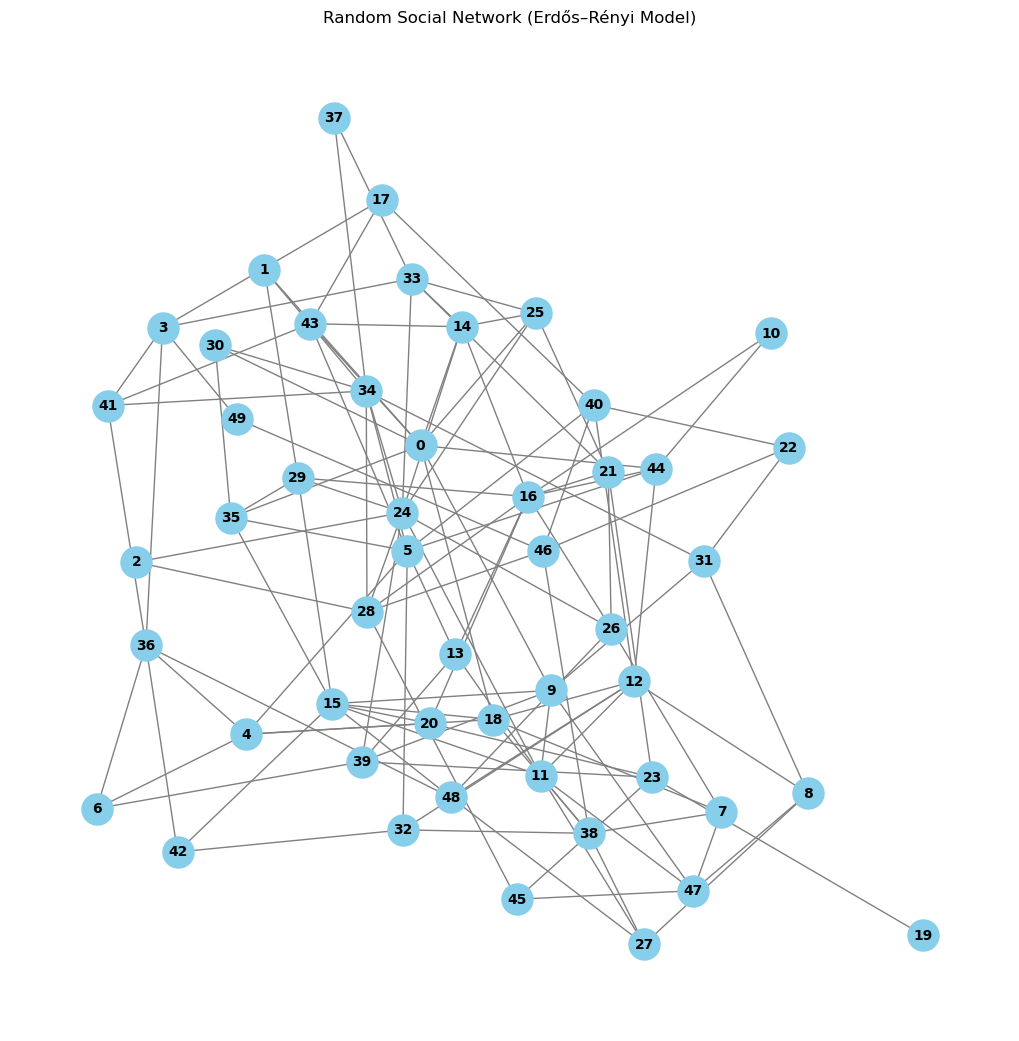

Basic Graph Metrics:
Degree distribution: [9, 3, 2, 5, 5, 8, 3, 4, 4, 6]...
Average path length: 2.5893877551020408
Average clustering coefficient: 0.13928571428571426


In [50]:
import networkx as nx
import matplotlib.pyplot as plt

def generate_random_social_network(num_nodes, edge_prob):
    """
    Generate a random social network using the Erdős–Rényi model.
    
    Parameters:
    - num_nodes: The number of nodes (individuals) in the network.
    - edge_prob: The probability of an edge between any pair of nodes.
    
    Returns:
    - G: The generated random graph (social network).
    """
    G = nx.erdos_renyi_graph(num_nodes, edge_prob)
    return G

def plot_network(G):
    """
    Visualize the social network graph using a spring layout.
    
    Parameters:
    - G: The graph to visualize.
    """
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G, seed=42)  # Spring layout for better visual distribution
    nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
    plt.title("Random Social Network (Erdős–Rényi Model)")
    plt.show()

def calculate_basic_metrics(G):
    """
    Calculate basic graph metrics for the social network.
    
    Parameters:
    - G: The graph to analyze.
    
    Returns:
    - metrics: Dictionary with basic graph metrics (degree distribution, average path length, clustering coefficient).
    """
    metrics = {}
    
    # Degree distribution (how many nodes have a specific degree)
    degree_distribution = [d for n, d in G.degree()]
    metrics['degree_distribution'] = degree_distribution
    
    # Average path length (how far apart nodes are on average)
    if nx.is_connected(G):
        metrics['avg_path_length'] = nx.average_shortest_path_length(G)
    else:
        metrics['avg_path_length'] = None  # If the graph is not connected
    
    # Clustering coefficient (local density of triangles in the graph)
    metrics['avg_clustering_coefficient'] = nx.average_clustering(G)
    
    return metrics

# Example usage:
num_nodes = 50  # Number of individuals in the network
edge_prob = 0.1  # Probability of an edge between any pair of nodes

# Step 1: Generate a random social network
social_network = generate_random_social_network(num_nodes, edge_prob)

# Step 2: Plot the network
plot_network(social_network)
dump_networkx_to_json(social_network, "social_network2.json")
# Step 3: Calculate basic metrics
metrics = calculate_basic_metrics(social_network)
print("Basic Graph Metrics:")
print(f"Degree distribution: {metrics['degree_distribution'][:10]}...")  # Display first 10 values
print(f"Average path length: {metrics['avg_path_length']}")
print(f"Average clustering coefficient: {metrics['avg_clustering_coefficient']}")


C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


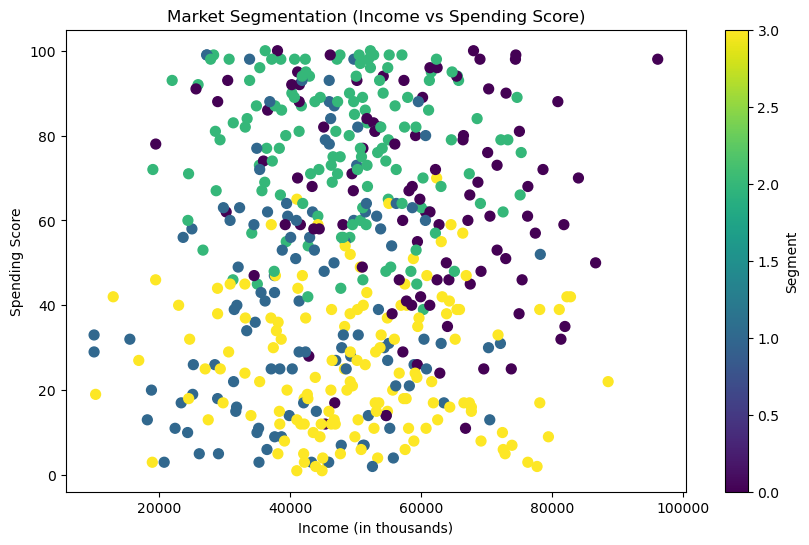

   Age  Income  Spending Score  Purchase Frequency  Family Size  \
0   56   81832              59                  12            4   
1   69   65486              39                   9            5   
2   46   27209              99                   6            1   
3   32   42736              54                   6            4   
4   60   69003              98                  12            2   

   Online Shopper  Segment  
0               1        0  
1               1        3  
2               0        1  
3               0        2  
4               1        0  


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Function to generate synthetic customer data
def generate_market_segmentation_data(num_customers=500):
    # Generate random features
    np.random.seed(42)

    # Generate random age (18-70)
    age = np.random.randint(18, 70, size=num_customers)

    # Generate random income (in thousands) (10,000 - 150,000)
    income = np.random.normal(50000, 15000, num_customers).astype(int)
    income = np.clip(income, 10000, 150000)  # Clip to keep values realistic

    # Generate random spending score (1-100)
    spending_score = np.random.randint(1, 101, size=num_customers)

    # Generate random purchase frequency (1-12 months)
    purchase_frequency = np.random.randint(1, 13, size=num_customers)

    # Generate random family size (1-5 members)
    family_size = np.random.randint(1, 6, size=num_customers)

    # Generate random online vs offline shopper (0: offline, 1: online)
    online_shopper = np.random.choice([0, 1], size=num_customers)

    # Create the DataFrame
    data = pd.DataFrame({
        'Age': age,
        'Income': income,
        'Spending Score': spending_score,
        'Purchase Frequency': purchase_frequency,
        'Family Size': family_size,
        'Online Shopper': online_shopper
    })
    
    return data

# Generate synthetic customer data
data = generate_market_segmentation_data()

# Perform KMeans clustering to segment the market (for example, 4 segments)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['Age', 'Income', 'Spending Score', 'Purchase Frequency', 'Family Size']])

kmeans = KMeans(n_clusters=4, random_state=42)
data['Segment'] = kmeans.fit_predict(scaled_data)

# Visualize the segmentation using income vs spending score
plt.figure(figsize=(10, 6))
plt.scatter(data['Income'], data['Spending Score'], c=data['Segment'], cmap='viridis', s=50)
plt.title("Market Segmentation (Income vs Spending Score)")
plt.xlabel("Income (in thousands)")
plt.ylabel("Spending Score")
plt.colorbar(label="Segment")
plt.show()

# Display first few rows of the dataset
print(data.head())


C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Charles\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


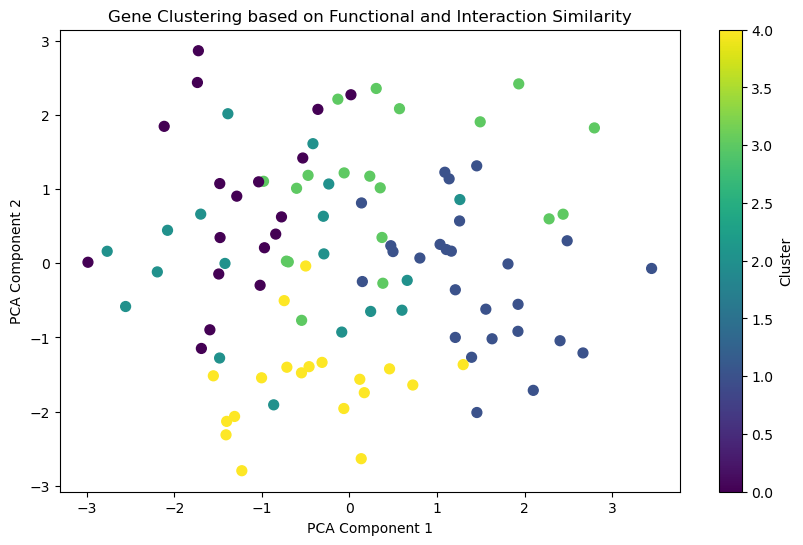

   Func_Feature_1  Func_Feature_2  Func_Feature_3  Func_Feature_4  \
0       -0.280118        1.346635        0.966446        0.335984   
1       -1.463805        1.412708        1.313507       -1.143530   
2        0.513495       -1.445661       -0.553280       -0.553658   
3        0.499089       -1.338852       -1.337910        1.677273   
4       -1.124527       -0.221367       -1.443854        1.525747   

   Func_Feature_5  Func_Feature_6  Func_Feature_7  Func_Feature_8  \
0       -0.994318       -1.255123       -1.446663        1.261537   
1       -0.907234       -1.162069       -0.583356        0.058350   
2        0.018212        0.880880       -0.950090        0.021270   
3        1.737741        0.959714       -0.582053       -1.446724   
4       -0.647547        0.464484       -0.557162        0.041828   

   Func_Feature_9  Func_Feature_10  Interaction_Feature_1  \
0        0.310068         0.857822              -1.057473   
1       -0.238530        -0.588927              

In [42]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Function to generate synthetic gene data with functional similarity and interaction similarity
def generate_gene_data(num_genes=100):
    np.random.seed(42)

    # Generate random functional data (e.g., Gene Ontology term similarity)
    func_similarity = np.random.rand(num_genes, 10)  # 10-dimensional functional feature space
    
    # Generate random interaction data (e.g., PPI or co-expression similarity)
    interaction_similarity = np.random.rand(num_genes, 8)  # 8-dimensional interaction feature space

    # Normalize the data
    scaler = StandardScaler()
    func_similarity = scaler.fit_transform(func_similarity)
    interaction_similarity = scaler.fit_transform(interaction_similarity)

    # Concatenate the two similarity matrices to form the feature matrix
    gene_data = np.concatenate([func_similarity, interaction_similarity], axis=1)
    
    return gene_data

# Generate synthetic data for genes
num_genes = 100
data = generate_gene_data(num_genes)

# Perform KMeans clustering based on both functional and interaction similarity
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(data)

# Create a DataFrame to view the results
genes_df = pd.DataFrame(data, columns=[f"Func_Feature_{i+1}" for i in range(10)] + [f"Interaction_Feature_{i+1}" for i in range(8)])
genes_df['Cluster'] = clusters

# Plotting the results (for visualization of the first 2 principal components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(data)

plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=genes_df['Cluster'], cmap='viridis', s=50)
plt.title("Gene Clustering based on Functional and Interaction Similarity")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Display first few rows of the clustered gene data
print(genes_df.head())
